In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Number of customers and transactions
n_customers = 250
n_transactions = 3500

customer_ids = np.arange(10001, 10001 + n_customers)

# Product information
products = [
    ("P001", "Wireless Earbuds", 29.99),
    ("P002", "Bluetooth Speaker", 45.00),
    ("P003", "Smart Watch", 79.99),
    ("P004", "Phone Case", 14.99),
    ("P005", "Power Bank", 24.99),
    ("P006", "USB-C Cable", 9.99),
    ("P007", "Laptop Stand", 39.99),
    ("P008", "Mechanical Keyboard", 89.99),
    ("P009", "Wireless Mouse", 34.99),
    ("P010", "Webcam", 59.99),
    ("P011", "Backpack", 49.99),
    ("P012", "Water Bottle", 19.99),
    ("P013", "Fitness Tracker", 64.99),
    ("P014", "Desk Lamp", 32.99),
    ("P015", "External SSD", 109.99),
    ("P016", "Gaming Headset", 69.99),
    ("P017", "Tablet Sleeve", 27.99),
    ("P018", "Smartphone", 499.99),
    ("P019", "Tablet", 299.99),
    ("P020", "Laptop", 899.99)
]

countries = [
    "United Kingdom",
    "India",
    "Germany",
    "France",
    "Spain",
    "Netherlands",
    "Australia",
    "Canada",
    "Italy",
    "Belgium"
]

# Customer purchasing groups
customer_types = np.random.choice(
    ["Low", "Regular", "High", "VIP"],
    size=n_customers,
    p=[0.45, 0.35, 0.16, 0.04]
)

transaction_rate = {
    "Low": 7,
    "Regular": 13,
    "High": 20,
    "VIP": 32
}

price_multiplier = {
    "Low": 0.80,
    "Regular": 1.00,
    "High": 1.20,
    "VIP": 1.45
}

# Generate transaction counts
transaction_counts = np.array([
    np.random.poisson(transaction_rate[t]) + 1
    for t in customer_types
])

# Adjust to exactly 3500 transactions
while transaction_counts.sum() < n_transactions:
    i = np.random.randint(0, n_customers)
    transaction_counts[i] += 1

while transaction_counts.sum() > n_transactions:
    valid = np.where(transaction_counts > 1)[0]
    i = np.random.choice(valid)
    transaction_counts[i] -= 1

# Date range
start_date = pd.Timestamp("2025-08-21")
end_date = pd.Timestamp("2026-08-20")

rows = []
invoice_number = 500001

for i, customer_id in enumerate(customer_ids):

    customer_type = customer_types[i]

    for _ in range(transaction_counts[i]):

        # Transaction date
        random_days = np.random.randint(
            0,
            (end_date - start_date).days + 1
        )

        date = start_date + pd.Timedelta(days=random_days)

        date = date + pd.Timedelta(
            hours=np.random.randint(8, 22),
            minutes=np.random.randint(0, 60)
        )

        # Product
        product = products[
            np.random.randint(len(products))
        ]

        stock_code = product[0]
        description = product[1]
        base_price = product[2]

        # Price
        price = base_price * np.random.normal(
            price_multiplier[customer_type],
            0.08
        )

        price = max(price, 2.99)
        price = round(price, 2)

        # Quantity
        if base_price < 30:
            quantity = np.random.choice(
                [1, 2, 3, 4],
                p=[0.55, 0.30, 0.10, 0.05]
            )
        else:
            quantity = np.random.choice(
                [1, 2, 3],
                p=[0.70, 0.25, 0.05]
            )

        country = np.random.choice(countries)

        rows.append([
            f"{invoice_number}",
            stock_code,
            description,
            quantity,
            date,
            price,
            customer_id,
            country
        ])

        invoice_number += 1

# Create DataFrame
df = pd.DataFrame(
    rows,
    columns=[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
)

# Sort by date
df = df.sort_values("InvoiceDate").reset_index(drop=True)

# Save CSV
df.to_csv(
    "customer_segmentation_dataset.csv",
    index=False
)

print("Dataset created successfully!")
print("Shape:", df.shape)
print("Number of customers:", df["CustomerID"].nunique())
print("Number of transactions:", len(df))

Dataset created successfully!
Shape: (3500, 8)
Number of customers: 250
Number of transactions: 3500


In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,501924,P005,Power Bank,2,2025-08-21 12:08:00,35.89,10140,Canada
1,502352,P007,Laptop Stand,1,2025-08-21 13:50:00,39.52,10171,Spain
2,503165,P017,Tablet Sleeve,1,2025-08-21 14:15:00,29.99,10231,Germany
3,500545,P004,Phone Case,2,2025-08-21 15:03:00,14.89,10042,United Kingdom
4,501682,P008,Mechanical Keyboard,1,2025-08-21 16:31:00,110.05,10121,Germany


In [3]:
print("Dataset Shape:", df.shape)
print("Unique Customers:", df["CustomerID"].nunique())
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (3500, 8)
Unique Customers: 250
Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


# Customer Segmentation Analysis

## Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

The analysis uses three behavioural features:

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How frequently a customer made purchases.
- **Monetary:** How much a customer spent.

After calculating the RFM features, the data will be standardized using StandardScaler and customer segments will be identified using K-Means clustering.

The resulting customer segments can be used to support targeted marketing strategies.

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3500 non-null   str           
 1   StockCode    3500 non-null   str           
 2   Description  3500 non-null   str           
 3   Quantity     3500 non-null   int64         
 4   InvoiceDate  3500 non-null   datetime64[us]
 5   UnitPrice    3500 non-null   float64       
 6   CustomerID   3500 non-null   int64         
 7   Country      3500 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 218.9 KB
None


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,3500.000000,3500,3500.000000,3500.000000
mean,1.432000,2026-02-17 08:26:09.600000,134.894494,10127.482571
min,1.000000,2025-08-21 12:08:00,6.220000,10001.000000
25%,1.000000,2025-11-17 18:18:00,28.017500,10063.000000
50%,1.000000,2026-02-16 17:06:30,48.325000,10127.000000
75%,2.000000,2026-05-18 15:02:30,91.460000,10190.000000
max,4.000000,2026-08-20 20:58:00,1440.570000,10250.000000
std,0.685625,NaN,232.329322,72.865942


In [6]:
print(df["Country"].value_counts())

Country
France            365
Australia         365
Canada            358
Belgium           357
India             355
Netherlands       354
United Kingdom    350
Italy             349
Spain             339
Germany           308
Name: count, dtype: int64


In [7]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,501924,P005,Power Bank,2,2025-08-21 12:08:00,35.89,10140,Canada,71.78
1,502352,P007,Laptop Stand,1,2025-08-21 13:50:00,39.52,10171,Spain,39.52
2,503165,P017,Tablet Sleeve,1,2025-08-21 14:15:00,29.99,10231,Germany,29.99
3,500545,P004,Phone Case,2,2025-08-21 15:03:00,14.89,10042,United Kingdom,29.78
4,501682,P008,Mechanical Keyboard,1,2025-08-21 16:31:00,110.05,10121,Germany,110.05


In [8]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2026-08-21 20:58:00


In [9]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
10001,113,10,780.58
10002,23,18,5518.01
10003,12,18,2975.84
10004,7,12,2454.66
10005,24,16,2356.64


In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,250.000000,250.000000,250.000000
mean,33.428000,14.000000,2561.425280
std,36.519742,7.215557,2246.280952
min,1.000000,2.000000,130.760000
25%,9.000000,9.000000,950.680000
50%,21.500000,12.000000,1904.220000
75%,42.000000,18.000000,3415.225000
max,204.000000,38.000000,12762.440000


In [11]:
print("Average Recency:", rfm["Recency"].mean())
print("Average Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())

Average Recency: 33.428
Average Frequency: 14.0
Average Monetary Value: 2561.4252800000004


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

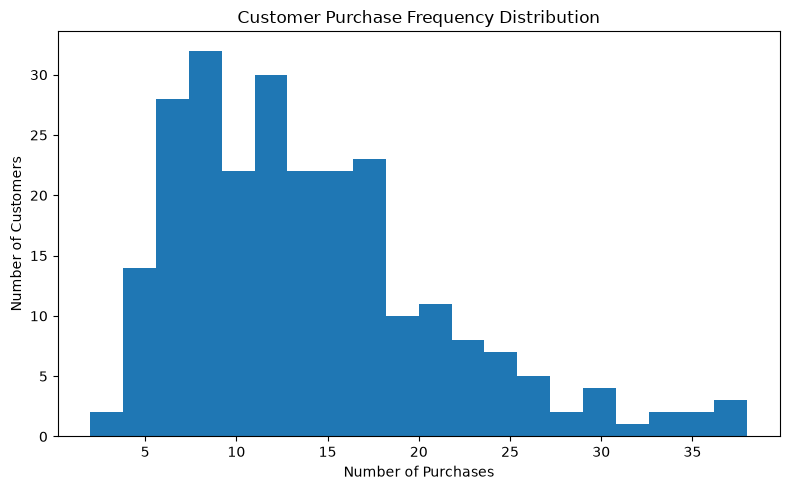

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(rfm["Frequency"], bins=20)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

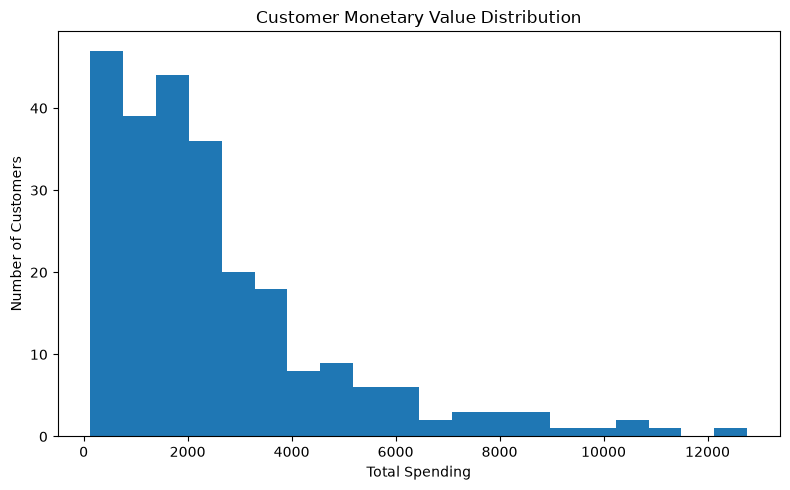

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(rfm["Monetary"], bins=20)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [18]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.3 MB/s  0:00:02 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 3.5 MB/s  0:00:05m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled_array = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
10001,2.183247,-0.555470,-0.794388
10002,-0.286117,0.555470,1.318854
10003,-0.587928,0.555470,0.184859
10004,-0.725115,-0.277735,-0.047625
10005,-0.258680,0.277735,-0.091349


In [20]:
import sklearn

print(sklearn.__version__)

1.9.0


In [21]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")

for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: {value:.2f}")

Inertia values:
K = 2: 426.55
K = 3: 263.19
K = 4: 193.31
K = 5: 156.07
K = 6: 125.27
K = 7: 112.12
K = 8: 99.39
K = 9: 89.55
K = 10: 83.43


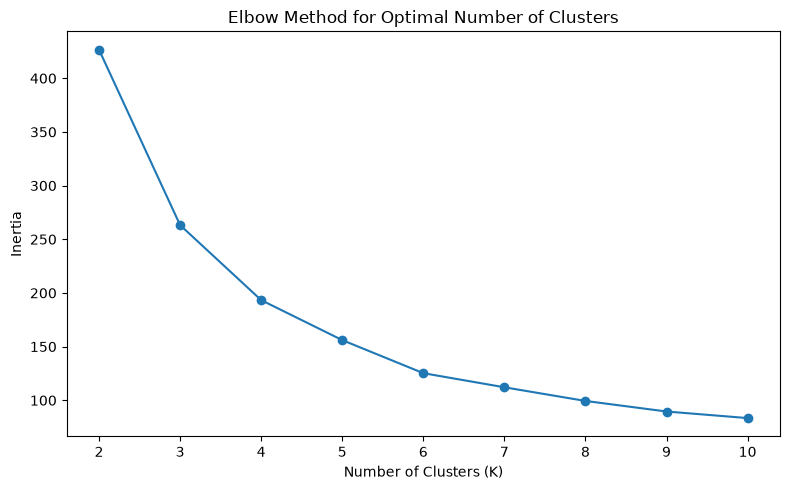

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

In [23]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
10001,113,10,780.58,0
10002,23,18,5518.01,3
10003,12,18,2975.84,3
10004,7,12,2454.66,1
10005,24,16,2356.64,3


In [24]:
cluster_size = rfm["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_size)

Customers in each cluster:
Cluster
0     40
1    121
2     19
3     70
Name: count, dtype: int64


In [25]:
cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,101.650000,8.000000,1036.909000
1,24.008264,10.371901,1472.457851
2,10.157895,29.894737,8439.515789
3,17.042857,19.385714,3719.453714


In [26]:
cluster_total_sales = rfm.groupby("Cluster")["Monetary"].sum()

print("Total monetary value by cluster:")
print(cluster_total_sales)

Total monetary value by cluster:
Cluster
0     41476.36
1    178167.40
2    160350.80
3    260361.76
Name: Monetary, dtype: float64


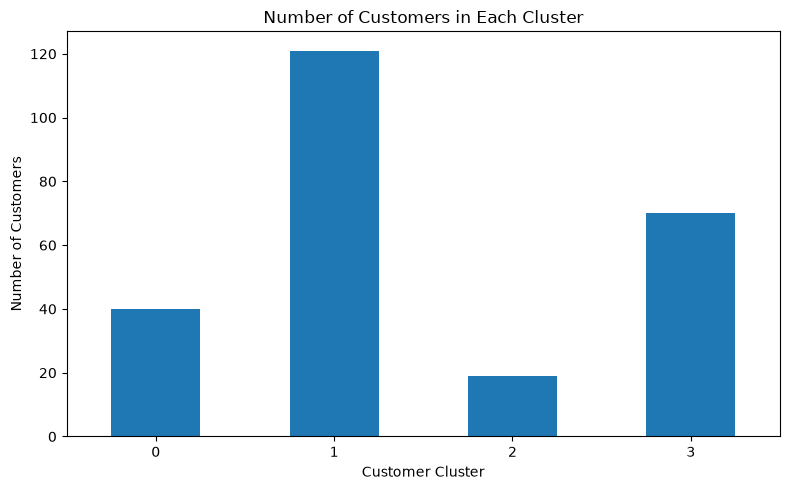

In [27]:
plt.figure(figsize=(8, 5))

cluster_size.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

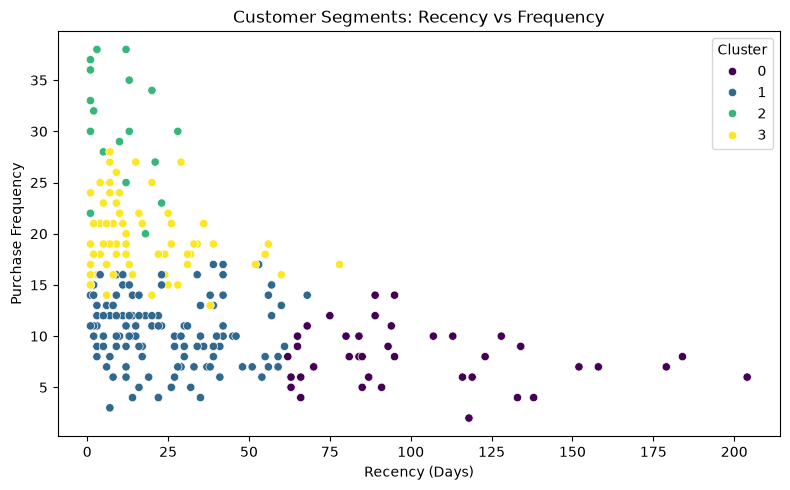

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.tight_layout()
plt.show()

In [29]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,101.650000,8.000000,1036.909000
1,24.008264,10.371901,1472.457851
2,10.157895,29.894737,8439.515789
3,17.042857,19.385714,3719.453714


In [30]:
cluster_size

Cluster
0     40
1    121
2     19
3     70
Name: count, dtype: int64

In [31]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,40,101.65,8.00,1036.91
1,121,24.01,10.37,1472.46
2,19,10.16,29.89,8439.52
3,70,17.04,19.39,3719.45


In [44]:
print("Cluster with highest average monetary value:")
print(cluster_summary["Avg_Monetary"].idxmax())

print("\nCluster with highest average frequency:")
print(cluster_summary["Avg_Frequency"].idxmax())

print("\nCluster with lowest average recency:")
print(cluster_summary["Avg_Recency"].idxmin())

Cluster with highest average monetary value:
2

Cluster with highest average frequency:
2

Cluster with lowest average recency:
2


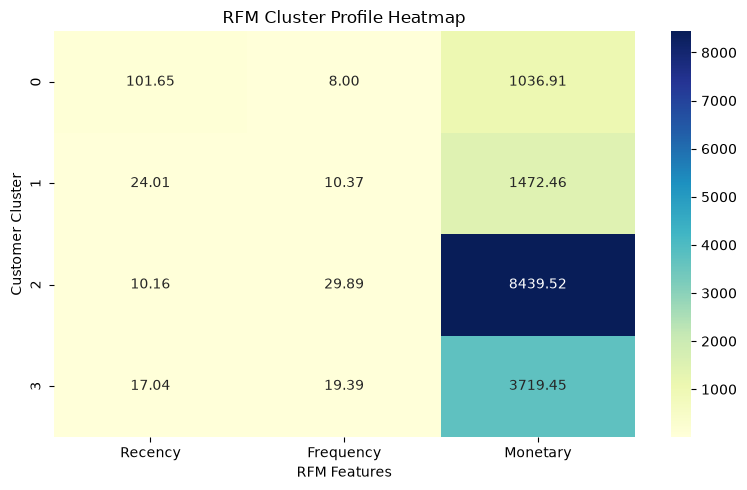

In [33]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("RFM Cluster Profile Heatmap")
plt.xlabel("RFM Features")
plt.ylabel("Customer Cluster")

plt.tight_layout()
plt.show()

In [34]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,101.65,8.00,1036.91
1,24.01,10.37,1472.46
2,10.16,29.89,8439.52
3,17.04,19.39,3719.45


In [37]:
cluster_names = {
    0: "Segment 0",
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3"
}

In [36]:
rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
10001,113,10,780.58,0,Segment 0
10002,23,18,5518.01,3,Segment 3
10003,12,18,2975.84,3,Segment 3
10004,7,12,2454.66,1,Segment 1
10005,24,16,2356.64,3,Segment 3


In [38]:
rfm.to_csv(
    "customer_segmentation_rfm_results.csv",
    index=True
)

print("RFM segmentation results saved successfully.")

RFM segmentation results saved successfully.


# Insights

The customer segmentation analysis grouped customers according to their purchasing behaviour using Recency, Frequency, and Monetary (RFM) features.

The clusters differ in terms of purchase recency, purchase frequency, and monetary value. These differences can help a business identify valuable customers, regular customers, customers requiring engagement, and customers with lower purchasing activity.

The cluster profiles and visualisations provide a basis for developing targeted marketing strategies for different customer groups.

# Marketing Recommendations

### High-Value Customers
Recommended strategy:
- Reward loyal customers with exclusive offers.
- Provide early access to new products.
- Encourage repeat purchases through loyalty programs.

### Regular Customers
Recommended strategy:
- Use personalized product recommendations.
- Provide targeted discounts to increase purchase frequency.

### Low-Activity Customers
Recommended strategy:
- Use re-engagement campaigns.
- Offer limited-time incentives to encourage another purchase.

### At-Risk Customers
Recommended strategy:
- Send personalized win-back campaigns.
- Provide relevant offers based on previous purchasing behaviour.

In [41]:
cluster_names = {
    0: "At-Risk / Low-Value Customers",
    1: "Regular Customers",
    2: "High-Value Loyal Customers",
    3: "Valuable Frequent Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
10001,113,10,780.58,0,At-Risk / Low-Value Customers
10002,23,18,5518.01,3,Valuable Frequent Customers
10003,12,18,2975.84,3,Valuable Frequent Customers
10004,7,12,2454.66,1,Regular Customers
10005,24,16,2356.64,3,Valuable Frequent Customers


In [42]:
print(rfm["Segment"].value_counts())

Segment
Regular Customers                121
Valuable Frequent Customers       70
At-Risk / Low-Value Customers     40
High-Value Loyal Customers        19
Name: count, dtype: int64


In [45]:
# Create final customer segment profile

final_profile = rfm.groupby("Segment").agg(
    Customers=("Recency", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

print("Final Customer Segment Profile:")
display(final_profile)

Final Customer Segment Profile:


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk / Low-Value Customers,40,101.65,8.00,1036.91
High-Value Loyal Customers,19,10.16,29.89,8439.52
Regular Customers,121,24.01,10.37,1472.46
Valuable Frequent Customers,70,17.04,19.39,3719.45


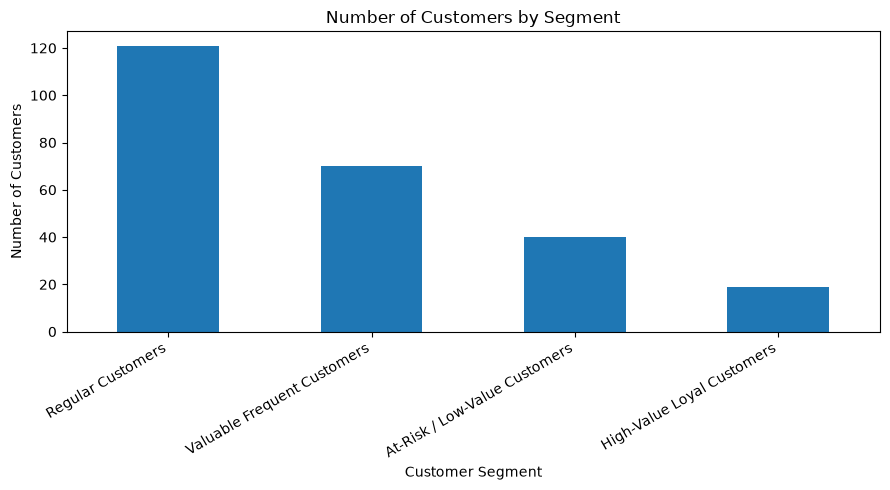

In [46]:
# Customer distribution by segment

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(9, 5))

segment_counts.plot(kind="bar")

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## Observation

The customer base has been divided into four segments based on Recency, Frequency, and Monetary purchasing behaviour. The segments differ in their level of engagement, purchase frequency, and spending. The High-Value Loyal Customers segment demonstrates the strongest purchasing behaviour, while the At-Risk / Low-Value Customers segment shows lower purchasing activity and less recent transactions.

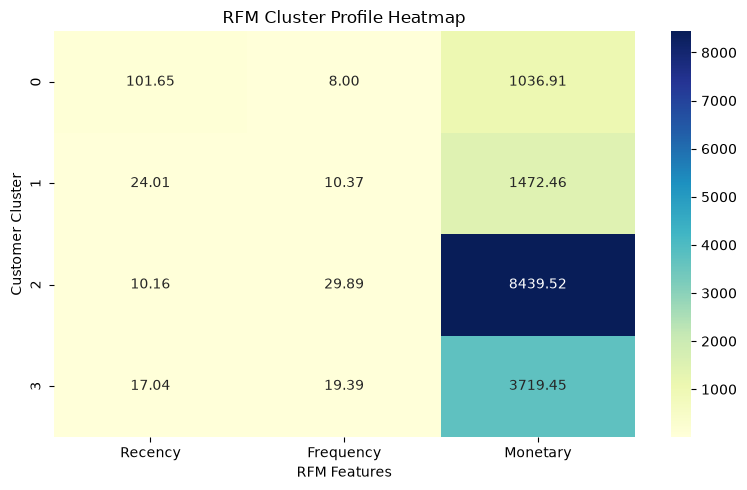

In [48]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("RFM Cluster Profile Heatmap")
plt.xlabel("RFM Features")
plt.ylabel("Customer Cluster")

plt.tight_layout()
plt.show()

In [49]:
rfm.to_csv("customer_segmentation_final_results.csv")

final_profile.to_csv("customer_segment_profile.csv")

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!


# Conclusion

The customer segmentation analysis successfully grouped customers into four distinct segments based on their purchasing behaviour using RFM analysis and K-Means clustering.

Recency, Frequency, and Monetary values were calculated for each customer and standardized using StandardScaler before applying K-Means clustering. The Elbow Method was used to determine the appropriate number of clusters, resulting in four customer segments.

The analysis showed clear differences between the identified customer groups. Cluster 2 was the strongest segment, with the lowest average recency of 10.16 days, the highest average purchase frequency of 29.89, and the highest average monetary value of 8439.52. This segment was therefore identified as the High-Value Loyal Customers segment.

Cluster 0 had the highest average recency of 101.65 days and comparatively lower frequency and monetary value, making it the least active customer segment. Cluster 1 represented regular customers, while Cluster 3 represented valuable frequent customers.

These segments can help businesses develop targeted marketing strategies. High-value customers can be retained through loyalty programs and exclusive benefits, while less active customers can be targeted through personalized re-engagement campaigns.

Overall, RFM analysis combined with K-Means clustering provides a useful data-driven approach for understanding customer purchasing behaviour and supporting targeted marketing decisions.